# Exploring the momentum/MACD features

Builds the 8-feature panel (`(date, ticker, feature)`) across the 26-ticker ETF universe using `trading_strategies.features`, then looks at distributions, cross-ticker agreement, and time series for a couple of names.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from trading_strategies.features import MACD_PAIRS, MOMENTUM_LOOKBACKS, compute_all_features

pd.set_option("display.max_columns", None)

## Load raw prices and build the feature panel

In [2]:
raw = pd.read_parquet("../data/raw.parquet")
raw = raw.sort_values(["ticker", "date"]).set_index("date")
raw.groupby("ticker").size().sort_values()

ticker
BND    4708
USO    4708
UNG    4708
TLT    4708
TIP    4708
SPY    4708
SLV    4708
SHY    4708
QQQ    4708
LQD    4708
IWM    4708
IEF    4708
HYG    4708
GLD    4708
FXY    4708
FXE    4708
FXC    4708
FXB    4708
FXA    4708
EWJ    4708
EFA    4708
EEM    4708
DBC    4708
DBA    4708
UUP    4708
VGK    4708
dtype: int64

In [3]:
def _features_for_one_ticker(group: pd.DataFrame) -> pd.DataFrame:
    return compute_all_features(group["close"])


panel = raw.groupby("ticker", group_keys=True).apply(_features_for_one_ticker)
panel.index.names = ["ticker", "date"]
panel = panel.reorder_levels(["date", "ticker"]).sort_index()

print(panel.shape)
panel.tail()

(122408, 8)


mom_1    mom_21    mom_63   mom_126   mom_252  \
date       ticker                                                     
2025-12-31 TLT    -1.456522 -0.723536 -0.549437 -0.078103  0.007934   
           UNG    -1.719660 -1.110353 -0.330042 -0.478956 -0.367020   
           USO    -0.522461 -0.366547 -0.430695 -0.476073 -0.251324   
           UUP    -0.110749 -1.356234 -0.322554  0.089465 -0.719180   
           VGK    -0.590453  0.976547  0.657625  0.971731  2.836572   

                   macd_8_24  macd_16_48  macd_32_96  
date       ticker                                     
2025-12-31 TLT     -0.784779   -0.914314   -0.492069  
           UNG     -0.844357   -0.687876   -0.456538  
           USO     -0.388621   -0.934969   -0.847348  
           UUP     -0.558616   -0.949879   -0.351039  
           VGK      0.943569    0.660923    0.886824

## Sanity checks: NaN warm-up period and distribution per feature

The longest lookback (252d momentum) plus the 252d winsorize window means each ticker needs ~500 trading days before every feature is populated.

In [4]:
nan_counts = panel.isna().sum()
first_fully_valid_date = panel.dropna().index.get_level_values("date").min()
print("NaNs per feature:\n", nan_counts)
print("\nFirst fully-valid date across all tickers/features:", first_fully_valid_date)

NaNs per feature:
 mom_1         1560
mom_21        1560
mom_63        1638
mom_126       3276
mom_252       6552
macd_8_24     8138
macd_16_48    8138
macd_32_96    8996
dtype: int64

First fully-valid date across all tickers/features: 2008-08-29 00:00:00


In [5]:
panel.dropna().describe()

,mom_1,mom_21,mom_63,mom_126,mom_252,macd_8_24,macd_16_48,macd_32_96
count,113412.000000,113412.000000,113412.000000,113412.000000,113412.000000,113412.000000,113412.000000,113412.000000
mean,0.007383,0.058681,0.111819,0.156042,0.186837,0.056096,0.066268,0.057431
std,0.973766,0.932850,0.945231,0.983718,1.063885,0.706230,0.765317,0.740266
min,-5.261171,-3.566926,-3.279277,-2.877258,-2.653871,-0.963780,-0.963780,-0.963780
25%,-0.592331,-0.579804,-0.557415,-0.561522,-0.595012,-0.680197,-0.792995,-0.760731
50%,0.036207,0.071521,0.105334,0.109471,0.079341,0.131556,0.202514,0.139887
75%,0.633759,0.701511,0.755447,0.819197,0.835884,0.773022,0.866933,0.828453
max,4.728057,4.301764,5.228606,5.371054,5.507561,0.963780,0.963780,0.963780


## Feature correlation

Are the 5 momentum lookbacks and 3 MACD variants actually adding independent information, or mostly redundant?

,mom_1,mom_21,mom_63,mom_126,mom_252,macd_8_24,macd_16_48,macd_32_96
mom_1,1.000000,0.231058,0.144054,0.107492,0.073328,0.092609,0.042576,0.024809
mom_21,0.231058,1.000000,0.608027,0.444517,0.315505,0.836955,0.659456,0.366428
mom_63,0.144054,0.608027,1.000000,0.697315,0.473018,0.629008,0.785261,0.712823
mom_126,0.107492,0.444517,0.697315,1.000000,0.657621,0.456102,0.614847,0.720460
mom_252,0.073328,0.315505,0.473018,0.657621,1.000000,0.324640,0.410719,0.508013
macd_8_24,0.092609,0.836955,0.629008,0.456102,0.324640,1.000000,0.799670,0.432863
macd_16_48,0.042576,0.659456,0.785261,0.614847,0.410719,0.799670,1.000000,0.738723
macd_32_96,0.024809,0.366428,0.712823,0.720460,0.508013,0.432863,0.738723,1.000000


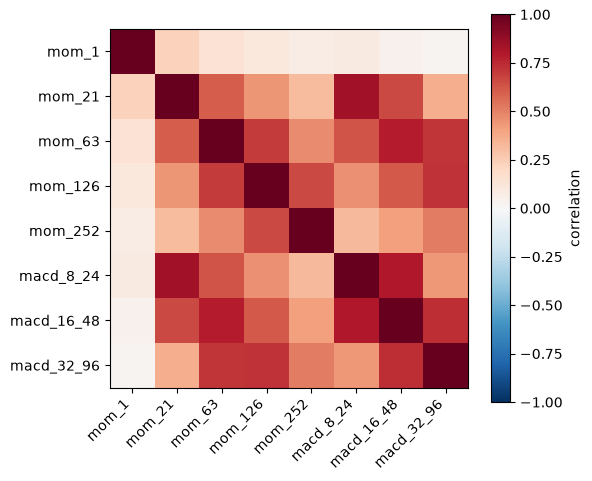

In [6]:
corr = panel.dropna().corr()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns)), corr.columns)
fig.colorbar(im, ax=ax, label="correlation")
fig.tight_layout()
corr

## Time series for one ticker

Pick a ticker and eyeball the feature time series against price, to check the features move sensibly with visible trends.

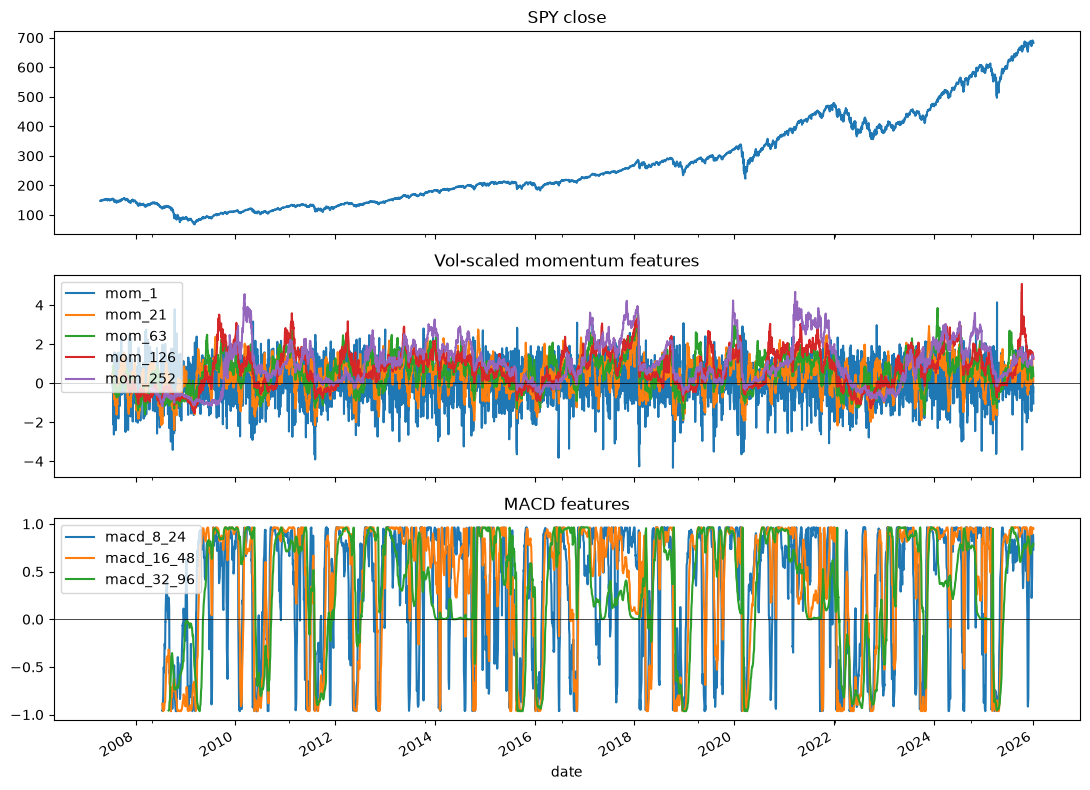

In [7]:
ticker = "SPY"
ticker_features = panel.xs(ticker, level="ticker")
ticker_close = raw.loc[raw["ticker"] == ticker, "close"]

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

axes[0].plot(ticker_close.index, ticker_close.values)
axes[0].set_title(f"{ticker} close")

mom_cols = [f"mom_{lb}" for lb in MOMENTUM_LOOKBACKS]
ticker_features[mom_cols].plot(ax=axes[1])
axes[1].set_title("Vol-scaled momentum features")
axes[1].axhline(0, color="black", linewidth=0.5)

macd_cols = [f"macd_{short}_{long}" for short, long in MACD_PAIRS]
ticker_features[macd_cols].plot(ax=axes[2])
axes[2].set_title("MACD features")
axes[2].axhline(0, color="black", linewidth=0.5)

fig.tight_layout()